<a href="https://colab.research.google.com/github/Khushi310105/Final_Year_Project/blob/main/Epilepsy1DChronoEEG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mne
!pip install pytorch-lightning
!pip install torchmetrics

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

import pytorch_lightning as pl
from pytorch_lightning import Trainer

import mne

In [3]:
csv_path = '/content/drive/MyDrive/EEG_data.csv'

df = pd.read_csv(csv_path)

cols_remove = df.columns.tolist()[16:-1]

df = df.loc[:, ~df.columns.isin(cols_remove)]

df.columns = df.columns.str.strip('EEG.')

print(df.head())

   video_id  subject_id          AF3           F7           F3          FC5  \
0         0           0  4210.641113  4179.102539  4287.948730  4235.384766   
1         0           0  4201.025879  4188.717773  4280.128418  4236.922852   
2         0           0  4203.205078  4182.820313  4282.820313  4231.025879   
3         0           0  4186.538574  4168.717773  4266.794922  4229.230957   
4         0           0  4232.436035  4216.922852  4306.922852  4270.769043   

            T7           P7           O1           O2           P8  \
0  4207.948730  4165.000000  4135.897461  4170.000000  4155.384766   
1  4209.615234  4152.436035  4130.128418  4149.487305  4149.487305   
2  4207.820313  4172.436035  4131.538574  4147.948730  4131.666504   
3  4202.179688  4155.384766  4128.333496  4151.666504  4136.666504   
4  4217.436035  4166.538574  4155.897461  4162.820313  4143.461426   

            T8          FC6           F4           F8          AF4  \
0  4157.179688  4610.384766  4388.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
groups = df.groupby(['subject_id', 'video_id'])

grp_keys = list(groups.groups.keys())


def convertDF2MNE(sub):

    info = mne.create_info(
        list(sub.columns),
        ch_types=['eeg'] * len(sub.columns),
        sfreq=128
    )

    info.set_montage('standard_1020')

    data = mne.io.RawArray(sub.T, info)

    data.set_eeg_reference()

    # IMPORTANT FILTER
    data.filter(l_freq=1, h_freq=30)

    epochs = mne.make_fixed_length_epochs(
        data,
        duration=3,
        overlap=2
    )

    return epochs.get_data()

In [6]:
all_data = []
all_labels = []
all_groups = []

for i, grpno in enumerate(grp_keys):

    grp = groups.get_group(grpno)

    grp = grp.drop(['subject_id', 'video_id'], axis=1)

    label = int(grp['subject_understood'].unique())

    grp = grp.drop('subject_understood', axis=1)

    data = convertDF2MNE(grp)

    for trial in data:

        all_data.append(trial)
        all_labels.append(label)
        all_groups.append(i)

all_data = np.array(all_data)
all_labels = np.array(all_labels)
all_groups = np.array(all_groups)

print(all_data.shape)

/tmp/ipykernel_6318/2482829557.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(grp['subject_understood'].unique())


Creating RawArray with float64 data, n_channels=14, n_times=2402
    Range : 0 ... 2401 =      0.000 ...    18.758 secs
Ready.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 423 samples (3.305 s)

Not setting metadata
16 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 16 events and 384 original time points ...
0 bad epochs droppe

/tmp/ipykernel_6318/2482829557.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(grp['subject_understood'].unique())
/tmp/ipykernel_6318/2482829557.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(grp['subject_understood'].unique())
/tmp/ipykernel_6318/2482829557.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(grp['subject_understood'].unique())
/tmp/ipykernel_6318/2482829557.py:11: DeprecationWarning: Conversion of a

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 423 samples (3.305 s)

Not setting metadata
53 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 53 events and 384 original time points ...
0 bad epochs dropped
Creating RawArray with float64 data, n_channels=14, n_times=6365
    Range : 0 ... 6364 =      0.000 ...    49.719 secs
Ready.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

/tmp/ipykernel_6318/2482829557.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(grp['subject_understood'].unique())
/tmp/ipykernel_6318/2482829557.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(grp['subject_understood'].unique())


0 bad epochs dropped
Creating RawArray with float64 data, n_channels=14, n_times=5930
    Range : 0 ... 5929 =      0.000 ...    46.320 secs
Ready.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 423 samples (3.305 s)

Not setting metadata
44 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 44 events and 384 original time points ..

/tmp/ipykernel_6318/2482829557.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(grp['subject_understood'].unique())
/tmp/ipykernel_6318/2482829557.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(grp['subject_understood'].unique())
/tmp/ipykernel_6318/2482829557.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(grp['subject_understood'].unique())


0 bad epochs dropped
Creating RawArray with float64 data, n_channels=14, n_times=3639
    Range : 0 ... 3638 =      0.000 ...    28.422 secs
Ready.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 423 samples (3.305 s)

Not setting metadata
26 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 26 events and 384 original time points ..

/tmp/ipykernel_6318/2482829557.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(grp['subject_understood'].unique())


In [7]:
class EEGDataset(Dataset):

    def __init__(self, X, y):

        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        x = self.X[idx]
        y = self.y[idx]

        # Z-score normalization
        x = (x - np.mean(x)) / (np.std(x) + 1e-8)

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        return x, y

In [8]:
class CNN1D(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv1d(14, 32, kernel_size=5)
        self.bn1 = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=5)
        self.bn2 = nn.BatchNorm1d(64)

        self.pool = nn.MaxPool1d(2)

        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(64 * 93, 128)

        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):

        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        x = self.dropout(x)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))

        x = self.fc2(x)

        return x

In [9]:
class ChronoNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.block1 = nn.Sequential(

            nn.Conv1d(14, 32, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.Conv1d(32, 32, kernel_size=4, stride=2),
            nn.ReLU(),

            nn.Conv1d(32, 32, kernel_size=8, stride=2),
            nn.ReLU()
        )

        self.gru1 = nn.GRU(
            input_size=32,
            hidden_size=32,
            batch_first=True,
            bidirectional=True
        )

        self.gru2 = nn.GRU(
            input_size=64,
            hidden_size=32,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(64, 1)

    def forward(self, x):

        x = self.block1(x)

        x = x.permute(0, 2, 1)

        x, _ = self.gru1(x)

        x, _ = self.gru2(x)

        x = x[:, -1, :]

        x = self.dropout(x)

        x = self.fc(x)

        return x

In [10]:
class EEGNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv1d(14, 16, kernel_size=64, padding=32)

        self.bn1 = nn.BatchNorm1d(16)

        self.depthwise = nn.Conv1d(
            16,
            32,
            kernel_size=16,
            groups=16,
            padding=8
        )

        self.bn2 = nn.BatchNorm1d(32)

        self.pool = nn.AvgPool1d(4)

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(32 * 96, 1)

    def forward(self, x):

        x = F.elu(self.bn1(self.conv1(x)))

        x = F.elu(self.bn2(self.depthwise(x)))

        x = self.pool(x)

        x = self.dropout(x)

        x = x.view(x.size(0), -1)

        x = self.fc(x)

        return x

In [11]:
class EEGClassifier(pl.LightningModule):

    def __init__(self, model, train_dataset, val_dataset):

        super().__init__()

        self.model = model

        self.train_dataset = train_dataset
        self.val_dataset = val_dataset

        self.criterion = nn.BCEWithLogitsLoss()

        self.train_acc = []
        self.val_acc = []

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):

        return torch.optim.Adam(
            self.parameters(),
            lr=1e-4
        )

    def train_dataloader(self):

        return DataLoader(
            self.train_dataset,
            batch_size=16,
            shuffle=True
        )

    def val_dataloader(self):

        return DataLoader(
            self.val_dataset,
            batch_size=16,
            shuffle=False
        )

    def training_step(self, batch, batch_idx):

        x, y = batch

        pred = self(x).squeeze(1)

        loss = self.criterion(pred, y)

        probs = torch.sigmoid(pred)

        preds = (probs > 0.5).int()

        acc = (preds == y.int()).float().mean()

        self.train_acc.append(acc.item())

        self.log('train_loss', loss)
        self.log('train_acc', acc)

        return loss

    def validation_step(self, batch, batch_idx):

        x, y = batch

        pred = self(x).squeeze(1)

        loss = self.criterion(pred, y)

        probs = torch.sigmoid(pred)

        preds = (probs > 0.5).int()

        acc = (preds == y.int()).float().mean()

        self.val_acc.append(acc.item())

        self.log('val_loss', loss)
        self.log('val_acc', acc)

        return loss

In [12]:
model_arch = CNN1D()

In [13]:
model_arch = ChronoNet()

In [14]:
model_arch = ChronoNet()

In [15]:
skf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

all_preds = []
all_true = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(all_data, all_labels, groups=all_groups)
):

    print(f'FOLD {fold + 1}')

    X_train = all_data[train_idx]
    y_train = all_labels[train_idx]

    X_val = all_data[val_idx]
    y_val = all_labels[val_idx]

    train_dataset = EEGDataset(X_train, y_train)
    val_dataset = EEGDataset(X_val, y_val)

    model = EEGClassifier(
        model_arch,
        train_dataset,
        val_dataset
    )

    trainer = Trainer(
        max_epochs=60,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        devices=1,
        log_every_n_steps=1
    )

    trainer.fit(model)

FOLD 1


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ChronoNet         │ 44.8 K │ train │     0 │
│ 1 │ criterion │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 44.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 44.8 K                                                                                               
Total estimated model params size (MB): 0.179                                                                      
Modules in train mode: 13                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

FOLD 5


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ChronoNet         │ 44.8 K │ train │     0 │
│ 1 │ criterion │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 44.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 44.8 K                                                                                               
Total estimated model params size (MB): 0.179                                                                      
Modules in train mode: 13                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=60` reached.


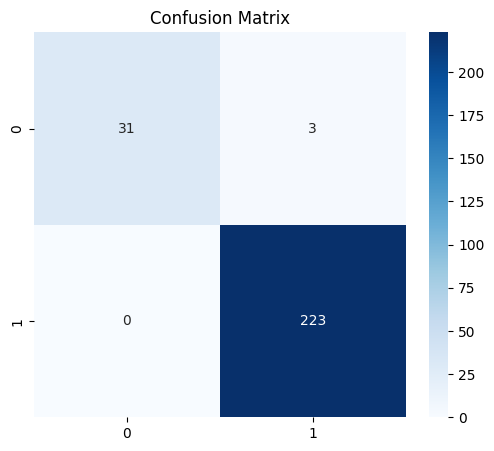

In [16]:
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for x, y in val_loader:

        x = x.to(model.device)

        outputs = model(x).squeeze(1)

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).int()

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(y.numpy())

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.show()

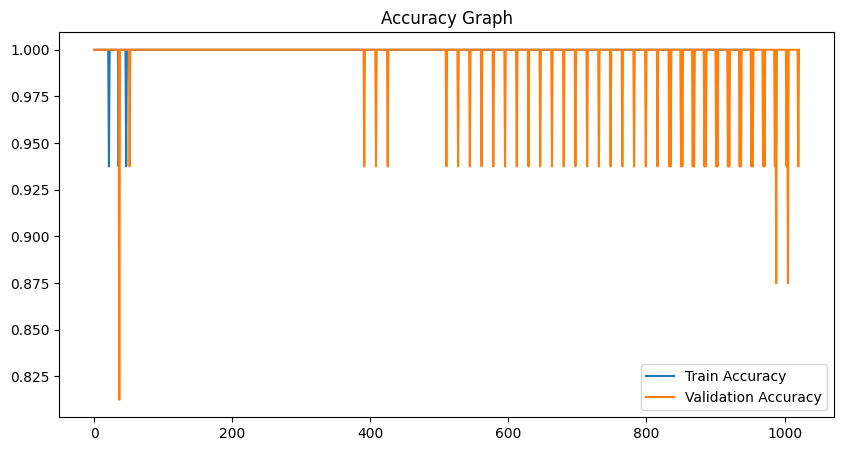

In [17]:
plt.figure(figsize=(10,5))

plt.plot(model.train_acc, label='Train Accuracy')

plt.plot(model.val_acc, label='Validation Accuracy')

plt.legend()

plt.title('Accuracy Graph')

plt.show()

In [18]:
# =========================
# FINAL ACCURACY
# =========================

final_acc = accuracy_score(
    true_labels,
    predictions
)

print(f'Final Accuracy: {final_acc * 100:.2f}%')

Final Accuracy: 98.83%
